# Reinforcement Learning

## Learning to Optimize Rewards

In Reinforcement Learning, a software *agent* makes *observations* and takes *actions* within an *environment*, and in return it receives *rewards*. Its objective is to learn to act in a way that will maximize its expected rewards over time. This is quite a broad setting, which can apply to a wide variety of tasks. Here are a few examples:

1. The agent can be the program controlling a robot. In this case, the environment is the real world, the agent observes the environment through a set of sensors such as a camera or touch sensors, and its actions consist of sending signals to activate motors. It may be programmed to get positive rewards whenever it approaches the target destination and negative rewards when it wastes time or goes the wrong direction.
2. The agent can be the program controlling Ms. Pac-Man. In this case the environment is a simulation of the Atari game, the actions are the nine possible joystick positions, and the observations are screenshots and the rewards are just game points.
3. Similarly, the agent can be the program playing a board game such as Go
4. The agent does not have to control a physically (or virtually) moving thing. For example, it can be a smart thermostat, getting positive rewards whenever it is close to the target temperature and saves energy, and negative rewards when humans need to tweak the temperature, so the agent must learn to anticipate human needs
5. The agent can observe stock market prices and deccide how much to buy or sell every second. Rewards are obviously monetary gains and losses.

Note that there may not be any positive rewards at all; for example, the agent may move around in a maze, getting a negative reward at every time step, so it had better find the exit quickly. There are many other examples of tasks to which Reinforcement Learning is well suited, such as self-driving cars, recommender systems, placing ads on a web page, or controlling where an image classification system should focus its attention.

## Policy Search

The algorithm a software agent uses to determine its actions is called its *policy*. The policy could be a neural network taking observations as inputs and outputting the action to take. The policy can be any algorithm you can think of and it does not have to be deterministic. For example, consider a robotic vacuum cleaner whose reward is the amount of dust it picks up in 30 minutes. Its policy could be to move forward with some probability **p** every second, or randomly rotate left or right with probability **1-p**. Since this policy involves some randomness, it is called a *stochastic policy*. The question is, how much dust will it pick up in 30 minutes?

How would you train such a robot? There are just two *policy parameters* you can tweak: the probability **p** and the angle range **r**. Once possible learning algorithm could be to try out many different values for these parameters and pick the combination that performs best. This is an example of *policy search*. When the *policy space* is too large finding a good set of parameters this way is like searching for a needle in a haystack.

Another way to explore the policy space is to use *generic algorithms*. For example, you could randomly create a first generation of 100 policies and try them out, then "kill" the 80 worst policies and make the 20 survivors produce 4 offspring each. An offspring is a copy of its parent plus some random variation. The surviving policies plus their offspring together constitute the second generation. You can continue to iterate through generations this way until you find a good policy.

Yet another approach is to use optimization techniques by evaluating the gradients of the rewards with regard to the policy parameters, then tweaking these parameters by following the gradients toward high rewards. This approach is called *policy gradients*.

## Introduction to OpenAI Gym

One of the challenges of Reinforcement Learning is that in order to train an agent, you first need to have a working environment. Training is hard and slow in the real world, so you generally need a *simulated environment* at least for bootstrap training. For example, you may use a library like PyBullet. OpenAI Gym is a toolkit that provides a wide variety of simulated environments. Below we'll create a CartPole environment. This is a 2D simulation in which a cart can be accelerated left or right in order to balance a pole placed on top of it.

In [1]:
import gymnasium as gym

env = gym.make('CartPole-v1')
obs = env.reset()
obs

(array([ 0.01313405, -0.0374325 , -0.04387984, -0.00013504], dtype=float32),
 {})

In [2]:
# Discrete(2) means that the possible actions are integers 0 and 1.
env.render()
env.action_space

C:\Users\Steph\anaconda3\envs\OReilly\Lib\site-packages\gymnasium\envs\classic_control\cartpole.py:251: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("CartPole-v1", render_mode="rgb_array")
  gym.logger.warn(


Discrete(2)

In [3]:
# obs is the new observation coordinates. reward is 1.0 at every step here so the goal is to keep going as long as possible
# done is True when the episode is over. Game is won or lost. info is metadata that can be useful for debugging
action = 1
obs, reward, done, _, info = env.step(action)
obs, reward, done, info

(array([ 0.01238541,  0.15829039, -0.04388255, -0.3063333 ], dtype=float32),
 1.0,
 False,
 {})

In [4]:
env.close()

In [5]:
'''Let's hardcode a simple policy that accelerates left when the pole is leaning toward the left and accelerates right when the pole is leaning toward the right.'''

def basic_policy(obs):
    angle = obs[2]
    return 0 if angle < 0 else 1

totals = []
for episode in range(500):
    episode_rewards = 0
    obs = env.reset()[0]
    for step in range(200):
        action = basic_policy(obs)
        obs, reward, done, _, info = env.step(action)
        episode_rewards += reward
        if done:
            break
    totals.append(episode_rewards)

In [6]:
import numpy as np

np.mean(totals), np.std(totals), np.min(totals), np.max(totals), np.median(totals)

(np.float64(42.008),
 np.float64(8.907745842804454),
 np.float64(24.0),
 np.float64(65.0),
 np.float64(41.0))

## Neural Network Policies

Let's create a neural network policy. It will estimate a probability for each action, and then we will select an action randomly, according to the estimated probabilities. In the case of the CartPole environment, there are just two possible actions (left or right), so we only need one output neuron. For example, if it outputs 0.7, then we will pick action 0 with 70% probability, or action 1 with 30% probability. You may wonder why we are picking a random action based on the probabilities given by the neural network, rather than just picking the action with the highest score. This approach lets the agent find the right balance between *exploring* new actions and *exploiting* the actions that are known to work well. 

In this particular environment, the past actions and observations can safely be ignored, since each observation contains the environment's full state. If there were some hidden state, then you might need to consider past actions and observations as well. For example, if the environment only revealed position of the cart but not its velocity, you would have to consider not only the current observation but also the previous observation in order to estimate the current velocity. Another example is when the observations are noisy; in that case, you generally want to use the past few observations to estimate the most likely current state.

If there are more than two possible actions, there would be one output neuron for each and we would use the softmax activation instead of the sigmoid activation.

In [7]:
import tensorflow as tf
from tensorflow import keras

n_inputs = 4

model = keras.models.Sequential([
    keras.layers.Input([n_inputs]),
    keras.layers.Dense(5, activation='elu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile()

## Evaluating Actions: The Credit Assignment Problem

If we knew what the best action was at each step, we could train the neural network as usual, by minimizing the cross entropy between the estimated probability distribution and the target probability distribution. However, in Reinforcement Learning the only guidance the agent gets is through rewards, and rewards are typically sparse and delayed. For example, if the agent mangages to balance the pole for 100 steps, how can it know which of the 100 actions it took were good and which of them were bad? All it knows is that the pole fell after the last action, but surely this last action is not entirely responsible. This is called the *credit assignment problem*: when the agent gets a reward, it is hard for it to know which actions should get credited (or blamed) for it.

To tackle this problem, a common strategy is to evaluate an action based on the sum of all the rewards that come after it, usually applying a *discount factor* $\gamma$ at each step. This sum of discounted rewards is called hte action's *return*. Typical discount factors vary from 0.9 to 0.99. With a discount factor of 0.95, rewards 13 steps into the future count roughly for half as much as immediate rewards (${0.95}^{13} = 0.5$).

We want to estimate how much better, or worse, an action is compared to the other possible actions, on average. This is called *action advantage*. For this, we must run many episodes and normalize all the action returns.

## Policy Gradients

PG algorithms optimize the parameters of a policy by following the gradients towards higher rewards. One popular class of PG algorithms, called Reinforce algorithms, was introduced back in 1992. Here is one common variant:

1. First, let the neural metwork policy play the game several times, and at each step, compute the gradients that would make the chosen action even more likely but don't apply those gradients yet.
2. Once you have run several episodes, compute each action's advantage (using the method described in the previous section).
3. If an action's advantage is positive, it means that the action was probably good, and you want to apply the gradients computed earlier to make the action even more likely to be chosen in the future. However, if the action's advantage is negative, it means the action was probably bad, and you want to apply the opposite gradients to make this action slightly less likely in the future. The solution is simply to multiply each gardient vector by the cooresponding action's advantage.
4. Finally, compute the mean of all the resulting gradient vectors, and use it to peform a Gradient Descent step.


Let's walk through the play_one_step function below:

1. Within the GradientTape block we start by calling the model, giving it a single observation (we reshape the observation so it becomes a batch containing a single instance, as the model expects a batch). This outputs the probability of going left.
2. Next, we sample a random float between 0 and 1 and we check whether it is greater than left_proba. The action will be False with probability left_proba) or True with probability 1 - (left_proba). Once we cast this Boolean to a number, the action will be 0 or 1 with the appropriate probability
3. Next, we define the target probability of going left: it is 1 minus the action (cast to a float). IF the action is 0 (left), then the target probability of going left will be 1. If the action is 1 (right) then the target probability will be 0.
4. Then we compute the loss using the given loss function, and we use the tape to compute the gradient of the loss with regard to the model's trainable variables. Again, these gradients will be tweaked later before we apply them depending on how good or bad the action turned out to be.
5. Finally, we play the selected action and we return the new observation, the reward, whether the episode is ended or not, and of course the gradients that we just computed.

The algorithm will use the play_multiple_episodes() function to play the game several times, then it will go back and look at all the rewards, discount them, and normalize them. Then the final loop will:

1. At each training iteration, this loop calls the play_multiple_episodes() function, which plays the game 10 times and returns all the rewards and gradients for every episode and step.
2. Then we call the discount_and_normalize_rewards() function to compute each action's normalized advantage (which in the code we call the final_reward). This provides a measure of how good or bad each action actually was, in hindsight.
3. Next, we go through each trainable varaible, and for each of them we compute the weighted mean of the gradients for that variable over all episodes and all steps, weighted by the final_reward.
4. Finally, we apply these mean gradients using the optimizer: the mode's trainable variables will be tweaked, and hopefully the policy will be a bit better.

Researchers try to find algorithms that work well even when the agent initially knowns nothing about the environment. However, **unless you are writing a paper, you should not hesitate to inject prior knowledge into the agent, as it will speed up training dramatically.** For example, since you know that the pole should be as vertical as possible, you could add negative rewards proportional to the pole's angle. This will make the rewards much less sparse and speed up training. Also, if you already have a reasonably good policy (e.g. hardcoded), you may want to train the neural network to imitate it before using policy gradients to improve it. The policy we just explored is highly *sample inefficient*, meaning it needs to explore the game for a very long time before it can make significant progress. However, it is the foundation of more powerful algorithms such as *Actor-Critic* algorithms.

In [8]:
def play_one_step(env, obs, model, loss_fn):
    obs = np.asarray(obs, dtype=np.float32)

    with tf.GradientTape() as tape:
        left_proba = model(obs[np.newaxis], training=True)

        # action = 0 means left, action = 1 means right
        action = tf.random.uniform([1, 1]) > left_proba

        # target is 1 if action was left, 0 if action was right
        y_target = 1.0 - tf.cast(action, tf.float32)

        loss = tf.reduce_mean(loss_fn(y_target, left_proba))

    grads = tape.gradient(loss, model.trainable_variables)

    obs, reward, terminated, truncated, info = env.step(int(action[0, 0].numpy()))
    done = terminated or truncated

    return obs, reward, done, info, grads


def play_multiple_episodes(env, n_episodes, n_max_steps, model, loss_fn):
    all_rewards = []
    all_grads = []

    for episode in range(n_episodes):
        current_rewards = []
        current_grads = []

        obs, info = env.reset()

        for step in range(n_max_steps):
            obs, reward, done, info, grads = play_one_step(env, obs, model, loss_fn)

            current_rewards.append(reward)
            current_grads.append(grads)

            if done:
                break

        all_rewards.append(current_rewards)
        all_grads.append(current_grads)

    return all_rewards, all_grads

def discount_rewards(rewards, discount_factor):
    discounted = np.array(rewards)
    for step in range(len(rewards) -2, -1, -1):
        discounted[step] += discounted[step + 1] * discount_factor
    return discounted

def discount_and_normalize_rewards(all_rewards, discount_factor):
    all_discounted_rewards = [
        discount_rewards(rewards, discount_factor)
        for rewards in all_rewards
    ]

    flat_rewards = np.concatenate(all_discounted_rewards)
    reward_mean = flat_rewards.mean()
    reward_std = flat_rewards.std()

    return [
        (discounted_rewards - reward_mean) / (reward_std + 1e-8)
        for discounted_rewards in all_discounted_rewards
    ]

n_iterations = 150
n_episodes_per_update = 10
n_max_steps = 200
discount_factor = 0.95
optimizer = keras.optimizers.Adam(learning_rate=0.01)
loss_fn = keras.losses.binary_crossentropy

for iteration in range(n_iterations):
    all_rewards, all_grads = play_multiple_episodes(
        env, n_episodes_per_update, n_max_steps, model, loss_fn
    )
    all_final_rewards = discount_and_normalize_rewards(all_rewards, discount_factor)
    all_mean_grads = []
    for var_index in range(len(model.trainable_variables)):
        mean_grads = tf.reduce_mean(
            [final_reward * all_grads[episode_index][step][var_index]
            for episode_index, final_rewards in enumerate(all_final_rewards) 
                for step, final_reward in enumerate(final_rewards)], 
            axis=0)
        all_mean_grads.append(mean_grads)
    optimizer.apply_gradients(zip(all_mean_grads, model.trainable_variables))

In [9]:
all_final_rewards[0:1], all_mean_grads

([array([ 0.52993579,  0.52992664,  0.52991701,  0.52990687,  0.5298962 ,
          0.52988497,  0.52987314,  0.5298607 ,  0.5298476 ,  0.52983381,
          0.52981929,  0.52980401,  0.52978793,  0.52977099,  0.52975317,
          0.52973441,  0.52971466,  0.52969388,  0.529672  ,  0.52964896,
          0.52962472,  0.5295992 ,  0.52957233,  0.52954406,  0.52951429,
          0.52948296,  0.52944998,  0.52941526,  0.52937871,  0.52934024,
          0.52929975,  0.52925713,  0.52921226,  0.52916503,  0.52911531,
          0.52906298,  0.5290079 ,  0.52894991,  0.52888887,  0.52882462,
          0.52875699,  0.5286858 ,  0.52861087,  0.52853198,  0.52844895,
          0.52836155,  0.52826954,  0.5281727 ,  0.52807075,  0.52796345,
          0.52785049,  0.52773159,  0.52760643,  0.52747468,  0.527336  ,
          0.52719002,  0.52703636,  0.52687461,  0.52670434,  0.52652512,
          0.52633646,  0.52613787,  0.52592884,  0.52570879,  0.52547717,
          0.52523336,  0.52497671,  0.

## Markov Decision Processes

Markov chains are stochastic processes with no memory. Such a process has a fixed number of states and it randomly evolves from one state to another at each step. Markov decision processes resemble Markov chains but with a twist: at east step an agent can choose one of several possible actions, and the transition probabilities depend on the chosen action. Moveover, some state transitions return some reward (positive or negative), and the agent's goal is to find a policy that will maximize reward over time. Richard Bellman found a way to estimate the *optimal state value* of any state *s*, noted ${V}^{*}(s)$ which is the sum of all discounted future rewards the agent can expect on average after it reaches a state *s*, assuming it acts optimally. This algorithm is an example of Dynamic Programming, which breaks down a complex problem into tractable subproblems that can be tackled iteratively.

Knowing the optimal state values can be useful, in particular to evaluate a policy, but it does not give us the optimal policy for the agent. Luckily, Bellman found a very similar algorithm to estimate the optimal *state-action values*, generally called **Q-Values** (Quality Values). The optimal Q-Value of the state-action pair (s, a), noted ${Q}^{*}(s, a)$ is the sum of discounted future rewards the agent can expect on average after it reaches the state *s* and chooses action *a*, but before it sees the outcome of this action, assuming it acts optimally after that action.

You start by initializing all the Q-Value estimates to zero, then you update them using the *Q-Value Iteration* algorithm. Once you have the optimal Q-Values, defining the optimal policy, noting $\pi^{*}(s)$ is trivial: when the agent is in state *s* it should choose the action with the highest Q-Value for that state $\pi^{*}(s) = argmax Q^{*}(s, a)$

In [10]:
transition_probabilities = [
    # shape = [s, a, s']
    [[0.7, 0.3, 0.0], [1.0, 0.0, 0.0], [0.8, 0.2, 0.0]],
    [[0.0, 1.0, 0.0], None, [0.0, 0.0, 1.0]],
    [None, [0.8, 0.1, 0.1], None]
]

rewards = [
    # shape = [s, a, s']
    [[10, 0, 0], [0, 0, 0], [0, 0, 0]],
    [[0, 0, 0], [0, 0, 0], [0, 0, -50]],
    [[0, 0, 0], [40, 0, 0], [0, 0, 0]]
]

possible_actions = [[0, 1, 2], [0, 2], [1]]

Q_values = np.full((3, 3), -np.inf)
for state, actions in enumerate(possible_actions):
    Q_values[state, actions] = 0.0

gamma = 0.90

for iteration in range(50):
    Q_prev = Q_values.copy()

    for s in range(3):
        for a in possible_actions[s]:
            Q_values[s, a] = np.sum([
                transition_probabilities[s][a][sp] *
                (rewards[s][a][sp] + gamma * np.max(Q_prev[sp]))
                for sp in range(3)
            ])

In [11]:
Q_values

array([[18.91891892, 17.02702702, 13.62162162],
       [ 0.        ,        -inf, -4.87971488],
       [       -inf, 50.13365013,        -inf]])

## Temporal Difference Learning

Reinforcement Learning problems with discrete actions can often be modeled as Markov decision processes. The *Temporal Difference Learning* (TD Learning) algorithm is very similar to the Value Iteration algorithm, but tweaked to take into account the fact that the agent has only partial knowledge of the MDP. In general, we assume that the agent intially knows only the possible states and actions, and nothing more. The agent uses an *exploration policy*-- for example, a purely random policy-- to explore the MDP, and as it progresses the TD Learning algorithm updates the estimates of the state values based on the transitions and rewards that are actually observed.

TD Learning has many similarities with Stochastic Gradient Descent, in particular the fact that it handles one sample at a time. Moreover, just like Stochastic GD, it can only truly converge if you gradually reduce the learning rate.

For each state *s*, this algorithm simply keeps track of a running average of the immediate rewards the agents gets upon leaving that state, plus the rewards it expects to get later (assuming it acts optimally).

## Q-Learning

Similarly, the Q-Learning algorithm is an adaptation of the Q-Value Iteration algorithm to the situation where the transition probabilities and the rewards are initially unknown. Q-Learning works by watching an agent play and gradually improving its estimates of the Q-Values. Once it has accurate Q-Value estimates then the optimal policy is choosing the action that has the highest Q-Value. Below is a simple implementation of the Q-Learning algorithm.

The algorithm will converge to the optimal Q-Values, but it will take many iterations. The Q-Learning algorithm is called an *off-policy* algorithm because the policy being trained is not necessarily the one being executed: in the code example the policy being executed (the exploration policy) is completely random, while the policy being trained will always choose the actions with the highest Q-Values.

In [12]:
def step(state, action):
    probas = transition_probabilities[state][action]
    next_state = np.random.choice([0, 1, 2], p=probas)
    reward = rewards[state][action][next_state]
    return next_state, reward

def exploration_policy(state):
    return np.random.choice(possible_actions[state])

alpha0 = 0.05 # initial learning rate
decay = 0.005 # learning rate decay
gamma = 0.90 # discount factor
state = 0 # initial state

for iteration in range(10000):
    action = exploration_policy(state)
    next_state, reward = step(state, action)
    next_value = np.max(Q_values[next_state])
    alpha = alpha0 / (1 + iteration * decay)
    Q_values[state, action] *= 1 - alpha
    Q_values[state, action] += alpha * (reward + gamma * next_value)
    state = next_state

Q_values[0:2]

array([[18.70702975, 17.05431611, 13.51173155],
       [ 0.        ,        -inf, -5.3824681 ]])

### Exploration Policies

A better option is to use *$\epsilon$-greedy policy*: at each step it actions randomly with a probability $\epsilon$, or greedily with probability $1 - \epsilon$ (choosing the action with the highest Q-Value). The advantage of the $\epsilon$-greedy policy (compared to a completely random policy) is that it will spend more and more time exploring the interesting parts of the environment, as the Q-Value estimates get better and better, while still spending some time visiting uknown regions of the MDP. **It is quite common to start with a higher value for $\epsilon$ like 1.0 and then gradually reducing it down to, say, 0.05.** Alternatively, rather than relying only on chance for exploration, another approach is to encourage the exploration policy to try actions that it has not tried much before.

### Approximate Q-Learning and Deep Q-Learning

The main problem with Q-Learning is that it does not scale well to large (or even medium) MDPs with many states and actions. The solution is to find a function $Q_{\theta}(s, a)$ that approximates the Q-Value of any state-action pair (s, a) using a manageable number of parameters (given by the parameter vector $\Theta$). This is called *Approximate Q-Learning*. For years it was recommended to use linear combinations of handcrafted features extracted from the state (e.g the distance of the closest ghosts in PacMan, their directions, and so on) to estimate Q-Values, but in 2013 DeepMind showed that using deep neural networks can work much better, especially for complex problems, and it does not require any feature engineering. A DNN used to estimate Q-Values is called a *Deep Q-Network* (DQN), and using a DQN for Approximate Q-Learning is called *Deep Q-Learning*. Specifically, we generally try to minimize the squared error between the estimated Q-Value Q(s, a) and the target Q-Value (or the Huber loss to reduce the algorithm's sensitivity to large errors).

## Implementing Deep Q-Learning

The first thing we need is a Deep Q-Network. In practice it's much more efficent to use a neural net that takes a state andd outputs an approximate Q-Value for each possible action. Instead of training the DQN based only on the latest experiences, we will store all experiences in a *replay buffer* (or *replay memory*), and we will sample a random training batch from it at each training iteration.

A *deque* is a linked list, where each element oints to the next one and to the previous one. It makes inserted and delting items very fast, but the longer the deque is, the slower random access will be. If you need a very large replay buffer, use a circular buffer; see the "Deque vs Rotating List" section of the notebook for an implementation {textbook notebook found on GitHub}.

Let's walk through the code below:
1. First we define some hyperparameters, and we create the optimizer and the loss function.
2. Then we create the training_step() function. It starts by sampling a batch of experiences, then it uses the DQN to predict the Q-Value for each possible action in each experience's next state. Since we assume that the agent will be playing optimally, we only keep the maximum Q-Value for each next state. Next, we use Equation 18-7 to compute the target Q-Value for each experience's state-action pair.
3. Next, we want to use the DQN to compute the Q-Value for each experienced state-action pair. However, the DQN will also output the Q-Values for the other possible actions, not just the action that was actually chosen by the agent. So we need to mask out all the Q-Values we do not need. The tf.one_hot() function maeks it easy to convert an array of action indices into such a mask. For example, if the first three experiences contain actions 1, 1, 0, respectively, then the mask will start with [[0, 1], [0, 1], [1, 0]]. We can then multiply the DQN's output with this mask and this will zero out all the Q-Values we do not want. We then sum over axis 1 to get rid of all the zeroes, keeping onlyu the Q-Values of the experienced state-action pairs. This gives us the Q_values tensor, containing one predicted Q-Value for each experience in the batch
4. Then we comput the loss: it is the mean squared error between the target and predicted Q-Values for the experienced state-action pairs.
5. Finally, we perform a Gradient Descecnt step to minimize the loss with regard to the model's trainable variables.

Training is straightforward. At each step, we first compute the epsilon value for the $\epsilon$-greedy policy: it will go from 1 down to 0.1, linearly, in a bit under 500 episodes. Then we call the play_one_step() function, which will use the $\epsilon$-greedy policy to pick an action, then execute it and record the experience in the replay buffer. If the episode is done, we exit the loop. Finally, if we are past the 50th episode, we call the training_step() function to train the model on one batch sampled from the replay buffer. **The reason we play 50 episodes without training is to give the replay buffer some time to fill up.**

In [15]:
from collections import deque

env = gym.make("CartPole-v1")

input_shape = env.observation_space.shape  # (4,)
n_outputs = env.action_space.n             # 2

replay_buffer = deque(maxlen=2000)
batch_size = 32
discount_factor = 0.95

optimizer = keras.optimizers.Adam(learning_rate=1e-3)
loss_fn = keras.losses.MeanSquaredError()

model = keras.models.Sequential([
    keras.layers.Input(shape=input_shape),
    keras.layers.Dense(32, activation="elu"),
    keras.layers.Dense(32, activation="elu"),
    keras.layers.Dense(n_outputs)
])

def epsilon_greedy_policy(state, epsilon=0):
    if np.random.rand() < epsilon:
        return np.random.randint(n_outputs)

    Q_values = model.predict(state[np.newaxis], verbose=0)
    return np.argmax(Q_values[0])

def sample_experiences(batch_size):
    indices = np.random.randint(len(replay_buffer), size=batch_size)
    batch = [replay_buffer[index] for index in indices]

    states, actions, rewards, next_states, dones = [
        np.array([experience[field_index] for experience in batch])
        for field_index in range(5)
    ]

    return states, actions, rewards, next_states, dones

def play_one_step(env, state, epsilon):
    action = epsilon_greedy_policy(state, epsilon)

    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    replay_buffer.append((state, action, reward, next_state, done))

    return next_state, reward, done, info

def training_step(batch_size):
    if len(replay_buffer) < batch_size:
        return

    states, actions, rewards, next_states, dones = sample_experiences(batch_size)

    states = states.astype(np.float32)
    next_states = next_states.astype(np.float32)
    rewards = rewards.astype(np.float32)
    dones = dones.astype(np.float32)

    next_Q_values = model.predict(next_states, verbose=0)
    max_next_Q_values = np.max(next_Q_values, axis=1)

    target_Q_values = rewards + (1 - dones) * discount_factor * max_next_Q_values

    mask = tf.one_hot(actions, n_outputs)

    with tf.GradientTape() as tape:
        all_Q_values = model(states)
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1)
        loss = loss_fn(target_Q_values, Q_values)

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

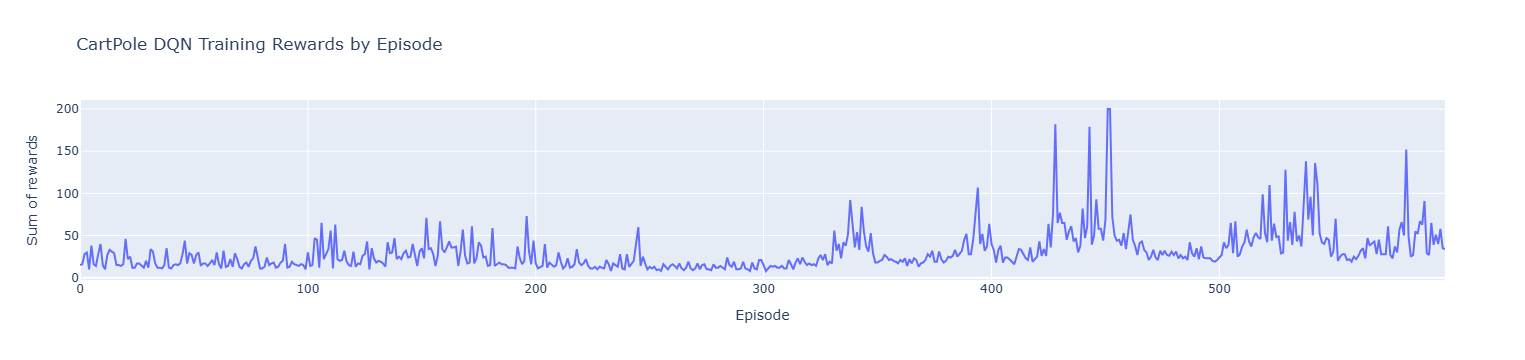

In [18]:
import plotly.express as px
import pandas as pd

episode_rewards = []

for episode in range(600):
    obs, info = env.reset()
    episode_reward = 0

    for step in range(200):
        epsilon = max(1 - episode / 500, 0.01)

        obs, reward, done, info = play_one_step(env, obs, epsilon)
        episode_reward += reward

        if done:
            break

    episode_rewards.append(episode_reward)

    if episode > 50:
        training_step(batch_size)

df_rewards = pd.DataFrame({
    "episode": range(len(episode_rewards)),
    "reward_sum": episode_rewards
})

fig = px.line(
    df_rewards,
    x="episode",
    y="reward_sum",
    title="CartPole DQN Training Rewards by Episode",
    labels={
        "episode": "Episode",
        "reward_sum": "Sum of rewards"
    }
)

fig.show()

At a certain point rewards skyrocketed to 200 but just a few episodes later it forget almost everything it learned and its performance dropped below 25! This is called *catastrophic forgetting* and it is one of the big problems facing virtually all RL algorithms: as the agent explores the environment, it updates its policy, but what it learns in one part of the environment may break what it learned earlier in other parts of the environment. The experiences are quite correlated, and the learning environment keeps changing-- this is not ideal for Gradient Descent! If you increase the size of the replay buffer, the algorithm will be less subject to this problem. But the truth is, RL is hard: training is often unstable, and you may need to try many hyperparameter values and random seeds before you find a combination that works well.

Reinforcement Learning is notoriously difficult, largely because of the training instabilities and the huge sensitivity to the choice of hyperparameter values and random seeds. As the researcher Andrej Karpathy put it: "Supervised learning wants to work but RL must be forced to work". You will need time, patience, perseverance, and perhaps a bit of luck too. This is a major reason RL is not as widely adopted as regular Deep Learning. But **there are a few real-world applications beyond AlphaGo and Atari games: for example, Google uses RL to optimize its data center costs, and it is used in some robotics applications, for hyperparameter tuning, and in recommender systems**. ***One important thing to remember about RL is that the loss metric is a poor indicator of the model's performance.***

## Deep Q-Learning Variants

### Fixed Q-Value Targets

In the basic Deep Q-Learning algorithm the model is used both to make predictions and to set its own targets. This can lead to a situation analogous to a dog chasing its own tail. To solve this problem, in their 2013 paper DeepMind researchers used two DQNs instead of one: the first is the *online model*, which learns at each step and is used to move the agent around, and the other is the *target model* used only to define the targets. The target model is just a clone of the online model. Since the target model is updated much less often than the online model, the Q-Value targets are more stable, the feedback loop we discussed earlier is dampened, and its effects are less severe. 

To stabalize training they used a tiny learning rate of 0.00025, they updated the target model only every 10,000 steps, and they used a very large replay buffer of 1 million experiences. They decreased epsilon very slowly from 1 to 0.01 in 1 million steps, and they let the algorithm run for 50 million steps.

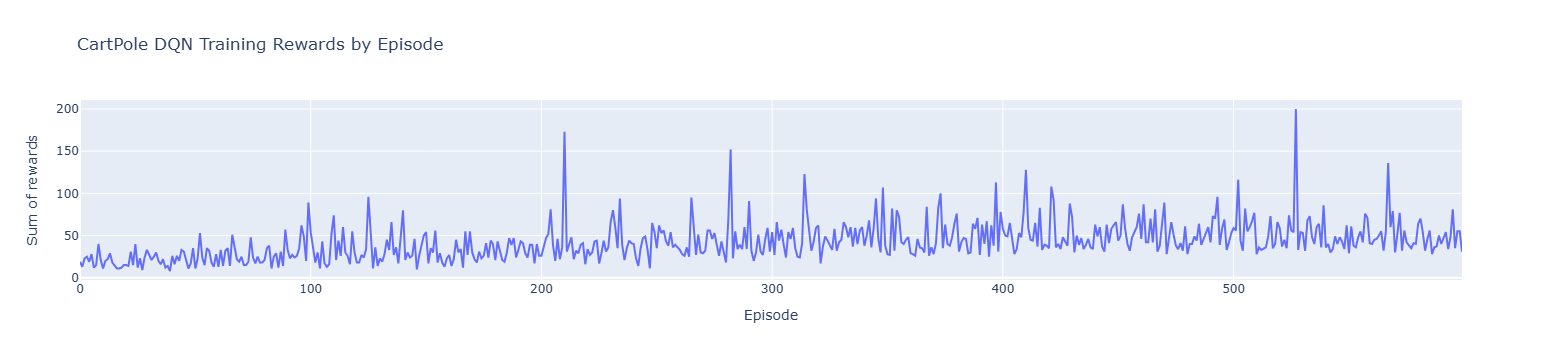

In [19]:
# Change 1: clone model
target = keras.models.clone_model(model)
target.set_weights(model.get_weights())

def training_step(batch_size):
    if len(replay_buffer) < batch_size:
        return

    states, actions, rewards, next_states, dones = sample_experiences(batch_size)

    states = states.astype(np.float32)
    next_states = next_states.astype(np.float32)
    rewards = rewards.astype(np.float32)
    dones = dones.astype(np.float32)

    # Change 2: use cloned model to predict next_Q_values
    next_Q_values = target.predict(next_states)
    max_next_Q_values = np.max(next_Q_values, axis=1)

    target_Q_values = rewards + (1 - dones) * discount_factor * max_next_Q_values

    mask = tf.one_hot(actions, n_outputs)

    with tf.GradientTape() as tape:
        all_Q_values = model(states)
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1)
        loss = loss_fn(target_Q_values, Q_values)

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

import plotly.express as px
import pandas as pd

episode_rewards = []

for episode in range(600):
    obs, info = env.reset()
    episode_reward = 0

    for step in range(200):
        epsilon = max(1 - episode / 500, 0.01)

        obs, reward, done, info = play_one_step(env, obs, epsilon)
        episode_reward += reward

        if done:
            break

    episode_rewards.append(episode_reward)

    # Change 3: update the weights of the cloned model every few episodes
    if not (episode % 50):
        target.set_weights(model.get_weights())

df_rewards = pd.DataFrame({
    "episode": range(len(episode_rewards)),
    "reward_sum": episode_rewards
})

fig = px.line(
    df_rewards,
    x="episode",
    y="reward_sum",
    title="CartPole DQN Training Rewards by Episode",
    labels={
        "episode": "Episode",
        "reward_sum": "Sum of rewards"
    }
)

fig.show()

### Double DQN

In 2015 DeepMind researchers tweaked their DQN algorithm, increasing its performance and somewhat stabilizing training. They called this variant *Double DQN*. The update was based on the observation that the target network is prone to overestimating Q-Values. To fix this, they proposed using the online model instead of the target model when selecting the best actions for the next states, and using the target model only to estimate the Q-Values for these best actions. Just a few months later another improvement to the DQN algorithm was proposed.

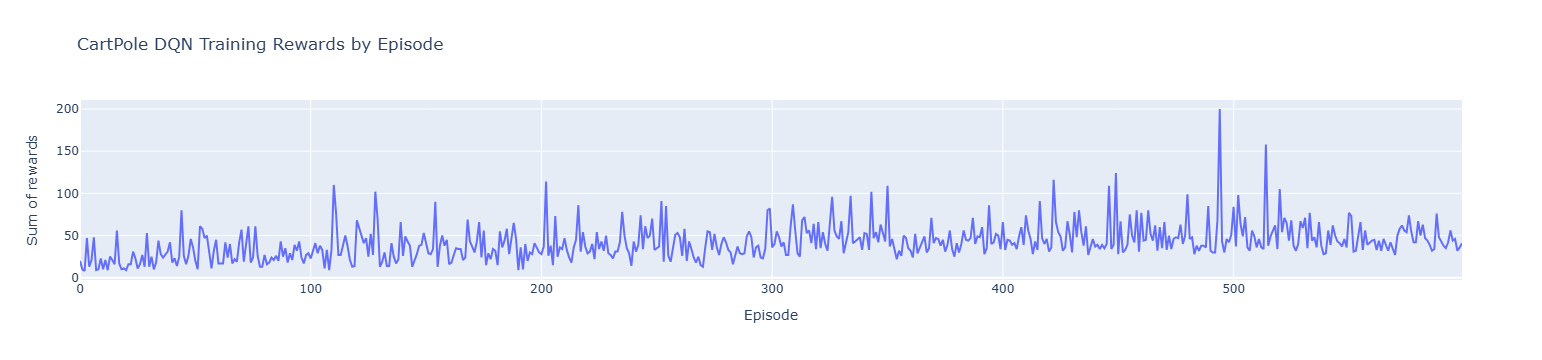

In [20]:
target = keras.models.clone_model(model)
target.set_weights(model.get_weights())

# Changes are isolated to the training_step, prior to with statement
def training_step(batch_size):
    if len(replay_buffer) < batch_size:
        return

    states, actions, rewards, next_states, dones = sample_experiences(batch_size)

    states = states.astype(np.float32)
    next_states = next_states.astype(np.float32)
    rewards = rewards.astype(np.float32)
    dones = dones.astype(np.float32)

    next_Q_values = model.predict(next_states)

    best_next_actions = np.argmax(next_Q_values, axis=1)

    next_mask = tf.one_hot(best_next_actions, n_outputs).numpy()

    next_best_Q_values = (target.predict(next_states) * next_mask).sum(axis=1)

    target_Q_values = rewards + (1 - dones) * discount_factor * next_best_Q_values

    mask = tf.one_hot(actions, n_outputs)

    with tf.GradientTape() as tape:
        all_Q_values = model(states)
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1)
        loss = loss_fn(target_Q_values, Q_values)

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

import plotly.express as px
import pandas as pd

episode_rewards = []

for episode in range(600):
    obs, info = env.reset()
    episode_reward = 0

    for step in range(200):
        epsilon = max(1 - episode / 500, 0.01)

        obs, reward, done, info = play_one_step(env, obs, epsilon)
        episode_reward += reward

        if done:
            break

    episode_rewards.append(episode_reward)

    # Change 3: update the weights of the cloned model every few episodes
    if not (episode % 50):
        target.set_weights(model.get_weights())

df_rewards = pd.DataFrame({
    "episode": range(len(episode_rewards)),
    "reward_sum": episode_rewards
})

fig = px.line(
    df_rewards,
    x="episode",
    y="reward_sum",
    title="CartPole DQN Training Rewards by Episode",
    labels={
        "episode": "Episode",
        "reward_sum": "Sum of rewards"
    }
)

fig.show()

### Prioritized Experience Replay

Instead of sampling experiences *uniformly* from the replay buffer, why not sample important experiences more frequently? This idea is called *importatance sampling* (IS) or *prioritized experience replay* (PER), and it was introduced in 2015 by DeepMind. **More specifically, experiences are considered "important" if they are likely to lead to fast learning progress.** But how do we estimate this? One reasonable approach is to measure the magnitude of the TD error. A large TD error indicates that a transition (s, r, s') is very surprising, and thus probably worth learning from. When an experience is recorded in the replay buffer, its priority is set to a very large value. Once it is sampled the TD error is computed and this experience's priority is to to $p = |\delta|$ (plus a small constant to ensure that every experience has a non-zero probability of being sampled). This probability *P* of sampling an experience with priority *p* is proporitional to $p^{\zeta}$, where $\zeta$ is a hyperparameter that controls how greedy we want importance sampling to be: when $\zeta = 0$, we just get uniform sampling and when $\zeta = 1$ we get full-blown importance sampling. The optimal value of $\zeta$ depends on the task.

**There's one catch, though: since the samples will be biased toward important experiences, we must compensate for this bias during training by downweighting the experiences according to their importance, or else the model will just overfit the important experiences. To be clear, we want important exeperiences to be sampled more often, bu this also means we must give them a lower weight during trianing.**

### Dueling DQN

The *Dueling DQN* algorithm (DDQN, not to be confused with the Double DQN, although both techniques can be easily combined) was introduced in yet another 2015 DeepMind paper. To understand how it works, we must first note that the Q-Value of a state-action pair (s, a) can be expressed as Q(s, a) = V(s) + A(s, a), where V(s) is the value of state s and A(s, a) is the *advantage* of taking the action a in state s, compared to all other possible actions in that state.

In a Dueling DQN, the model estimates both the value of the state and the advantage of each possible action. Since the best action should have an advantage of 0, the model subtracts the maximum predicted advantage from all predicted advantages. The rest of the algorithm is just the same as earlier.

Generally, many RL techinques can be combined, as DeepMind demonstrated in a 2017 paper. The paper's authors combined six different techniques into an agent called Rainbow, which largely outperformed the state of the art. Unfortunately, implementing all of these techniques, debugging them, fine-tuning them, and of course training the models can require a huge amount of work. So instead of reinventing the wheel, it is often best to reuse scalable and well-tested libraries, such as TF-Agents.

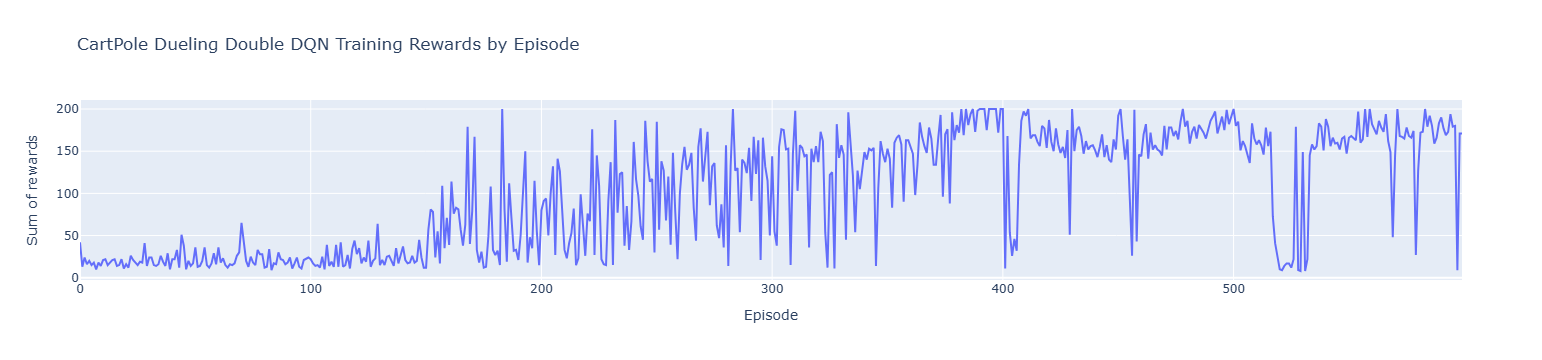

In [25]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import plotly.express as px
import pandas as pd

# -------------------------
# Recreate model from scratch
# -------------------------

input_states = keras.layers.Input(shape=[4])

hidden1 = keras.layers.Dense(32, activation="elu")(input_states)
hidden2 = keras.layers.Dense(32, activation="elu")(hidden1)

state_values = keras.layers.Dense(1)(hidden2)
raw_advantages = keras.layers.Dense(n_outputs)(hidden2)

# Dueling DQN aggregation
advantages = raw_advantages - keras.ops.mean(
    raw_advantages,
    axis=1,
    keepdims=True
)

Q_values = state_values + advantages

model = keras.Model(inputs=input_states, outputs=Q_values)

target = keras.models.clone_model(model)
target.set_weights(model.get_weights())

# Recreate optimizer after recreating model
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

# Optional but useful in notebooks: explicitly bind optimizer to this model's variables
optimizer.build(model.trainable_variables)

loss_fn = keras.losses.MeanSquaredError()


# -------------------------
# Training step
# -------------------------

def training_step(batch_size):
    if len(replay_buffer) < batch_size:
        return

    states, actions, rewards, next_states, dones = sample_experiences(batch_size)

    states = states.astype(np.float32)
    next_states = next_states.astype(np.float32)
    rewards = rewards.astype(np.float32)
    dones = dones.astype(np.float32)
    actions = actions.astype(np.int32)

    # Double DQN:
    # Online model selects action
    next_Q_values = model.predict(next_states, verbose=0)
    best_next_actions = np.argmax(next_Q_values, axis=1)

    # Target model evaluates selected action
    next_target_Q_values = target.predict(next_states, verbose=0)
    next_mask = tf.one_hot(best_next_actions, n_outputs)

    next_best_Q_values = tf.reduce_sum(
        next_target_Q_values * next_mask,
        axis=1
    )

    target_Q_values = rewards + (1 - dones) * discount_factor * next_best_Q_values
    target_Q_values = tf.cast(target_Q_values, tf.float32)

    mask = tf.one_hot(actions, n_outputs)

    with tf.GradientTape() as tape:
        all_Q_values = model(states)
        selected_Q_values = tf.reduce_sum(all_Q_values * mask, axis=1)
        loss = loss_fn(target_Q_values, selected_Q_values)

    grads = tape.gradient(loss, model.trainable_variables)

    # Optional safety filter
    grads_and_vars = [
        (g, v) for g, v in zip(grads, model.trainable_variables)
        if g is not None
    ]

    optimizer.apply_gradients(grads_and_vars)


# -------------------------
# Episode loop
# -------------------------

episode_rewards = []

for episode in range(600):
    obs, info = env.reset()
    episode_reward = 0

    for step in range(200):
        epsilon = max(1 - episode / 500, 0.01)

        obs, reward, done, info = play_one_step(env, obs, epsilon)
        episode_reward += reward

        training_step(batch_size)

        if done:
            break

    episode_rewards.append(episode_reward)

    if episode % 50 == 0:
        target.set_weights(model.get_weights())


# -------------------------
# Plot rewards
# -------------------------

df_rewards = pd.DataFrame({
    "episode": range(len(episode_rewards)),
    "reward_sum": episode_rewards
})

fig = px.line(
    df_rewards,
    x="episode",
    y="reward_sum",
    title="CartPole Dueling Double DQN Training Rewards by Episode",
    labels={
        "episode": "Episode",
        "reward_sum": "Sum of rewards"
    }
)

fig.show()

## The TF-Agents Library

The TF-Agents library is a Reinforcement Learning library. It provides many off-the-shelf environments, plus it supports the PyBullet library (for 3D physics simulation), DeepMind's DM Control library, and Unity's ML-Agents library. It is fast, scalable, easy to use, and customizable: you can create your own environments and neural nets, and you can customize pretty much any component.

### Installing TF-Agents

python3 -m pip install -U tf-agents or use anaconda to install to a specific venv. The takeaway is to install the tf-agents library to your environment however you do.

### TF-Agents Environments

For learning RL concepts: skip TF-Agents unless the book requires it. Your manual DQN code is better pedagogically because you see the replay buffer, target network, Bellman target, epsilon-greedy policy, and gradient update directly.

For practical RL experiments: use Stable-Baselines3 first. It is PyTorch-based, actively maintained, and explicitly positioned as reliable RL implementations.

For scalable/distributed RL: use Ray RLlib. Ray is actively maintained as a broader AI compute framework, and RLlib is its scalable RL library.

## Overview of Some Popular RL Algorithms

Let's take a quick look at a few popular RL algorithms:

1. *Actor-Critic Algorithms*
   > A family of RL algorithms that combine Policy Gradients with Deep Q-Networks. An Actor-Critic agent contains two neural networks: a policy net and a DQN. The DQN is trained normally, by learning from the agent's experiences. The policy net learns differently (and much faster) than in regular PG: instead of estimating the value of each action by going through multiple episodes, then summing the future discounted rewards for each action, and finally normalizing them, the agent (actor) relies on the action values estimated by the DQN (critic). **It's a bit like an athlete (the agent) learning with the help of a coach (the DQN)**
2. *Asynchronous Advantage Actor-Critic (A3C)*
   > An important Actor-Critic variant introduced by DeepMind researchers in 2016, where multiple agents learn in parallel, exploring different copies of the environment. At regular intervals, but asynchronously (hence the name), each agent pushes some weight updates to a master network, then it pulls the latest weights from that network. Each agent thus contributes to improving the master network and benefits from what the other agents have learned. Moreover, instead of estimating the Q-Values, the DQN estimates the advantage of each action (hence the second A in the name), which stabilizes training.
3. *Advantage Actor-Critic (A2C)*
   > A variant of the A3C algorithm that removes the asynchronicity. All model updates are sychronous, so gradient updates are performed over large batches, which allows the model to better utilize the power of the GPU
4. *Soft Actor-Critic (SAC)*
   > An Actor-Critic variant proposed in 2018 by UC Berkeley researchers. It learns not only rewards, but also to maximize the entropy of its actions. In other words, it tries to be as unpredictable as possible while still getting as many rewards as possible. This encourages the agent to explore the environment, which speeds up training, and makes it less likely to repeatedly execute the same action when the DQN produces imperfect estimates. This algorithm has demonstrated an amazing sample efficient (contrary to all the previous algorithms, which learn very slowly). SAC is available in TF-Agents
5. *Proximal Policy Optimization (PPO)*
   > An algorithm based on A2C that clips the loss function to avoid excessively large weight updates (which often lead to training instabilities). PPO is a simplification of the previous *Trust Region Policy Optimization (TRPO)* algorithm, developed by OpenAI researchers. OpenAI made the news in 2019 when their AI called OpenAI Five, based on the PPO algorithm, defeated the world champions in Dota 2. PPO is also available in TF-Agents
6. *Curiosity-based exploration*
   > A recurring problem in RL is the sparsity of the rewards, which makes learning very slow and inefficient. UC Berkeley researchers have proposed an exciting way to tackle this issue: why not ignore the rewards and just make the agent extremely curious to explore the environment? The rewards thus become intrinsic to the agent, rather than coming from the environment. Similarly, stimulating curiosity in a child is more likely to give good results than purely rewarding the child for good grades. **How does this work? The agent continuously tries to predict the outcome of its actions, and it seeks situations where the outcome does not match its predictions. In other words, it wants to be surprised. If the outcome is predictable (boring), it goes elsewhere.** However, if the outcome is unpredictable but the agent notices that it has no control over it, it also gets bored after a while. With only curiosity, the authors succeeded in training an agent at many video games: even though the agent gets no penalty for losing, the game starts over, which is boring so it learns to avoid it.

# Exercises

**1. How would you define Reinforcement Learning? How it is different from regular supervised or unsupervised learning?**

**My Answer** <br>
Reinfocement Learning is very akin to trial and error learning often exploring a probability space within a set environment. The main contrast between RL and regular ML techniques is the optimization method. It is environment specific whether RL seeks to maximize reward, minimize penalty, or in some cases neither whereas regular ML optimizes by minimizing the value of the loss function through backpropagation.

**Book Answer** <br><br>

**2. Can you think of three possible applications of RL that were not mentioned in this chapter? For each of them, what is the environment? What is the agent? What are some possible actions? What are the rewards?**

**My Answer** <br>
1. Protein synthesis.
   > Environment: A biochemical simulation environment: molecular dynamics simulator, protein-folding model, reaction network, or lab-in-the-loop assay<br>
   > Agent: A policy/model proposing amino acid sequences, mutations, or reaction steps<br>
   > Possible actions: Add/substitute/delete amino acids; choose reaction conditions; choose synthesis pathway steps<br>
   > Rewards: Stability, binding affinity, low toxicity, synthesizability, yield, catalytic activity<br>
2. Financial markets.
   > Environment: Market simulator/backtester, including prices, order book, volatility, transaction costs, slippage, margin, and broker constraints<br>
   > Agent: Neural Network.<br>
   > Possible Actions: Buy, Hold, Sell.<br>
   > Rewards: Return<br>
3. Robotic grasping
   > Environment: Physics simulator or real-world robot workspace<br>
   > Agent: Control policy/neural network<br>
   > Possible Actions: Move joints, rotate wrist, open/close gripper, adjust force<br>
   > Rewards: Successful grasp, object placed correctly, minimal damage, speed, energy efficiency<br>

**Book Answer** <br><br>

**3. What is the discount factor? Can the optimal policy change if you modify the discount factor?**

**My Answer** <br>

The discount factor effectively reduces the value of future rewards and yes the optimal policy changes if you modify how valuable or invaluable future rewards are.

**Book Answer** <br><br>

**4. How do you measure the performance of a Reinforcement Learning agent?**

**My Answer** <br>

Notably, the loss function of the policy agent is not a good measurement for RL. The main measurement used in this chapter was looking at the sum of rewards in an episode. This generalizes to the performance metric being tracked.

**Book Answer** <br><br>

**5. What is the credit assignment problem? When does it occur? How can you alleviate it?**

**My Answer** <br>

The *credit assignment problem*: when the agent gets a reward, it is hard for it to know which actions should get credited (or blamed) for it. To tackle this problem, a common strategy is to evaluate an action based on the sum of all the rewards that come after it, usually applying a *discount factor* $\gamma$ at each step. This sum of discounted rewards is called hte action's *return*.

**Book Answer** <br><br>

**6. What is the point of using a replay buffer?**

**My Answer** <br>

In practice it's much more efficent to use a neural net that takes a state and outputs an approximate Q-Value for each possible action. Instead of training the DQN based only on the latest experiences, we can store all experiences in a *replay buffer* (or *replay memory*), and sample a random training batch from it at each training iteration.

**Book Answer** <br><br>

**7. What is an off-policy RL algorithm?**

**My Answer** <br>

One example of an *off-policy* algorithm is the Q-Learning algorithm because the policy being trained is not necessarily the one being executed: in the code example the policy being executed (the exploration policy) is completely random, while the policy being trained will always choose the actions with the highest Q-Values.

**Book Answer** <br><br>

**8. Use policy gradients to solve OpenAI Gym's LunarLander-v2 environment. You will need to install Box2D dependencies (python3 -m pip install -U gym[box2d])**

In [32]:
import gymnasium as gym
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers


ENV_NAME = "LunarLander-v3"  # use "LunarLander-v2" for older Gym
GAMMA = 0.99
LR = 3e-4
MAX_EPISODES = 3000
SOLVED_SCORE = 200
PRINT_EVERY = 25
ENTROPY_COEF = 0.01
VALUE_COEF = 0.5


class ActorCritic(tf.keras.Model):
    def __init__(self, obs_dim, action_dim):
        super().__init__()

        self.dense1 = layers.Dense(128, activation="relu")
        self.dense2 = layers.Dense(128, activation="relu")

        self.policy_logits = layers.Dense(action_dim)
        self.value = layers.Dense(1)

    def call(self, x):
        x = self.dense1(x)
        x = self.dense2(x)

        logits = self.policy_logits(x)
        value = tf.squeeze(self.value(x), axis=-1)

        return logits, value


def discounted_returns(rewards, dones, gamma=GAMMA):
    returns = []
    R = 0.0

    for reward, done in zip(reversed(rewards), reversed(dones)):
        if done:
            R = 0.0
        R = reward + gamma * R
        returns.insert(0, R)

    return np.array(returns, dtype=np.float32)


def sample_action(logits):
    action = tf.random.categorical(logits, num_samples=1)
    return int(action[0, 0].numpy())


def train():
    env = gym.make(ENV_NAME)

    obs_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    model = ActorCritic(obs_dim, action_dim)
    optimizer = tf.keras.optimizers.Adam(learning_rate=LR)

    episode_rewards = []

    for episode in range(1, MAX_EPISODES + 1):
        obs, _ = env.reset()

        states = []
        actions = []
        rewards = []
        dones = []

        total_reward = 0.0
        done = False

        while not done:
            obs_tensor = tf.convert_to_tensor(obs[None, :], dtype=tf.float32)

            logits, _ = model(obs_tensor)
            action = sample_action(logits)

            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            states.append(obs)
            actions.append(action)
            rewards.append(reward)
            dones.append(done)

            total_reward += reward
            obs = next_obs

        states = tf.convert_to_tensor(np.array(states), dtype=tf.float32)
        actions = tf.convert_to_tensor(np.array(actions), dtype=tf.int32)
        returns = tf.convert_to_tensor(
            discounted_returns(rewards, dones),
            dtype=tf.float32
        )

        # Optional but helps stabilize learning
        returns = (returns - tf.reduce_mean(returns)) / (tf.math.reduce_std(returns) + 1e-8)

        with tf.GradientTape() as tape:
            logits, values = model(states)

            action_masks = tf.one_hot(actions, action_dim)

            log_probs_all = tf.nn.log_softmax(logits)
            probs_all = tf.nn.softmax(logits)

            selected_log_probs = tf.reduce_sum(action_masks * log_probs_all, axis=1)

            advantages = returns - values

            policy_loss = -tf.reduce_mean(selected_log_probs * tf.stop_gradient(advantages))
            value_loss = tf.reduce_mean(tf.square(returns - values))

            entropy = -tf.reduce_mean(
                tf.reduce_sum(probs_all * log_probs_all, axis=1)
            )

            loss = (
                policy_loss
                + VALUE_COEF * value_loss
                - ENTROPY_COEF * entropy
            )

        grads = tape.gradient(loss, model.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, 1.0)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        episode_rewards.append(total_reward)

        if episode % PRINT_EVERY == 0:
            avg_reward = np.mean(episode_rewards[-100:])

            print(
                f"Episode {episode:4d} | "
                f"Reward: {total_reward:8.2f} | "
                f"Avg100: {avg_reward:8.2f} | "
                f"Loss: {loss.numpy():.4f}"
            )

            if avg_reward >= SOLVED_SCORE:
                print(f"Solved at episode {episode} with Avg100={avg_reward:.2f}")
                break

    env.close()

    model.save_weights("lunarlander_actor_critic_tf.weights.h5")
    return model


def watch(model_path="lunarlander_actor_critic_tf.weights.h5"):
    env = gym.make(ENV_NAME, render_mode="human")

    obs_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    model = ActorCritic(obs_dim, action_dim)

    # Build model before loading weights
    dummy_obs = tf.zeros((1, obs_dim), dtype=tf.float32)
    model(dummy_obs)

    model.load_weights(model_path)

    obs, _ = env.reset()
    done = False
    total_reward = 0.0

    while not done:
        obs_tensor = tf.convert_to_tensor(obs[None, :], dtype=tf.float32)

        logits, _ = model(obs_tensor)
        action = int(tf.argmax(logits[0]).numpy())

        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        total_reward += reward

    print("Evaluation reward:", total_reward)
    env.close()


if __name__ == "__main__":
    model = train()
    watch()

Episode   25 | Reward:  -172.93 | Avg100:  -163.41 | Loss: 0.5534
Episode   50 | Reward:  -152.91 | Avg100:  -165.72 | Loss: 0.4508
Episode   75 | Reward:  -324.01 | Avg100:  -164.48 | Loss: 0.3736
Episode  100 | Reward:  -148.52 | Avg100:  -151.36 | Loss: 0.3253
Episode  125 | Reward:  -109.35 | Avg100:  -147.00 | Loss: 0.2566
Episode  150 | Reward:  -269.21 | Avg100:  -143.96 | Loss: 0.3553
Episode  175 | Reward:  -106.42 | Avg100:  -150.86 | Loss: 0.3938
Episode  200 | Reward:  -113.20 | Avg100:  -159.87 | Loss: 0.1555
Episode  225 | Reward:   -21.43 | Avg100:  -153.82 | Loss: 0.3411
Episode  250 | Reward:     4.28 | Avg100:  -152.85 | Loss: 0.4645
Episode  275 | Reward:  -161.48 | Avg100:  -132.70 | Loss: 0.0378
Episode  300 | Reward:  -127.09 | Avg100:  -129.70 | Loss: 0.4451
Episode  325 | Reward:  -170.63 | Avg100:  -134.29 | Loss: -0.1512
Episode  350 | Reward:  -105.06 | Avg100:  -133.60 | Loss: 0.0733
Episode  375 | Reward:   -83.01 | Avg100:  -136.78 | Loss: 0.1797
Episode  

Here’s the algorithm sequence in plain English.

## Actor-Critic Policy Gradient for LunarLander

### 1. Create the game environment

Start LunarLander.

The lander begins in the air with some position, speed, angle, and contact-state information.

The environment gives the model a snapshot like:

```text
Where am I?
How fast am I moving?
Am I tilted?
Are my legs touching the ground?
```

---

### 2. Feed the current state into the neural network

The neural network looks at the current situation.

It has two jobs:

```text
Actor:  Choose what action to take.
Critic: Estimate how good or bad the current situation is.
```

The possible actions are:

```text
0 = do nothing
1 = fire left engine
2 = fire main engine
3 = fire right engine
```

---

### 3. The actor picks an action

The actor does not always choose the action it currently thinks is best.

Instead, it outputs probabilities, like:

```text
Do nothing:        10%
Fire left engine:  20%
Fire main engine:  55%
Fire right engine: 15%
```

Then it samples from those probabilities.

This is important because early in training the model needs to explore. It has to try different things to learn what works.

---

### 4. The lander takes the action

The chosen action is sent to the game.

The environment updates:

```text
The lander moves.
Velocity changes.
Angle changes.
Fuel is used.
The lander may crash or land.
```

Then the environment returns a reward.

Examples:

```text
Good landing: large positive reward
Crashing: large negative reward
Moving closer to the landing pad: positive reward
Using fuel: small penalty
Tilting or moving too fast: bad
```

---

### 5. Store what happened

For each step in the episode, save:

```text
State observed
Action taken
Reward received
Whether the episode ended
```

This creates one full flight history.

---

### 6. Finish the episode

The episode ends when the lander:

```text
lands successfully
crashes
goes out of bounds
hits the time limit
```

At this point, we now know how good or bad the whole flight was.

---

### 7. Calculate the long-term reward for each step

The model does not only care about the immediate reward.

It asks:

```text
From this moment onward, how much total reward did I eventually get?
```

So if firing the main engine now leads to a safe landing later, that action gets credit even if the immediate reward was small.

This is the “discounted return.”

In plain terms:

```text
Earlier actions get credit for helping future success,
but future rewards are slightly discounted because they are farther away.
```

---

### 8. The critic estimates whether each state was good

The critic looks at each saved state and says:

```text
I think this state was worth about X reward.
```

Then we compare that estimate to what actually happened.

Example:

```text
Critic predicted: 50
Actual future reward: 120
Difference: +70
```

That difference is called the **advantage**.

---

### 9. Compute advantage

Advantage means:

```text
Was this action better or worse than expected?
```

Formula:

```text
advantage = actual future reward - critic's predicted value
```

Interpretation:

```text
Positive advantage:
The action worked better than expected.
Make that action more likely next time.

Negative advantage:
The action worked worse than expected.
Make that action less likely next time.
```

---

### 10. Update the actor

The actor is rewarded for actions that led to better-than-expected outcomes.

If firing the main engine helped save the lander, the model increases the probability of firing the main engine in similar future situations.

If firing the side engine caused instability, the model decreases the probability of that action in similar situations.

In plain English:

```text
Do more of what worked.
Do less of what failed.
```

---

### 11. Update the critic

The critic is trained to make better predictions.

If it underestimated a good situation, it adjusts upward.

If it overestimated a bad situation, it adjusts downward.

In plain English:

```text
Get better at judging how promising each situation is.
```

---

### 12. Add a small exploration bonus

The algorithm also rewards the actor slightly for not becoming too certain too early.

This prevents behavior like:

```text
Always fire the main engine
```

before the model has learned the environment properly.

This is called **entropy regularization**.

In plain English:

```text
Keep exploring until you are confident.
```

---

### 13. Repeat for many episodes

The model repeats this process over and over:

```text
Fly
Observe
Act
Crash or land
Score the flight
Learn from the result
Try again
```

Over time, the lander learns:

```text
slow down before landing
stay upright
avoid overusing fuel
move toward the landing pad
touch down gently
```

---

## The full sequence

```text
1. Start a LunarLander episode.
2. Observe the current state.
3. Neural network predicts:
   - action probabilities
   - estimated value of the state
4. Sample an action from the probabilities.
5. Send the action to the environment.
6. Receive the next state and reward.
7. Store the state, action, reward, and done flag.
8. Repeat until the lander lands or crashes.
9. Calculate total future reward for each step.
10. Compare actual reward to critic's estimate.
11. Use the difference as the advantage.
12. Update the actor to favor better-than-expected actions.
13. Update the critic to predict future reward more accurately.
14. Repeat across many episodes.
```

## Simplest analogy

Think of the actor as the **pilot** and the critic as the **flight instructor**.

The pilot tries different controls.

The instructor watches and says:

```text
That move was better than expected.
That move was worse than expected.
This situation was more dangerous than I thought.
This situation was safer than I thought.
```

After thousands of attempts, the pilot learns a reliable landing strategy.
